importing libraries for EDA

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Data = '/content/drive/MyDrive/sdg 7.1.1.xlsx'
df = pd.read_excel(Data)

In [ ]:
df.head()

,SeriesCode,SeriesName,Indicator,SeriesID,GeoAreaCode/Reference Area Code,Ref_Area_Type,GeoAreaName/Reference Area Name,TimePeriod,Value,Units,Nature,Location,Reporting Type,FootNote,Source,ISOalpha3,Type
0,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,2.9 Regional (Regional Commissions),ECA: African Union Commission,2000,37.713057,PERCENT,E,ALLAREA,G,NaN,World Bank,NaN,Region
1,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,2.9 Regional (Regional Commissions),ECA: African Union Commission,2000,24.544702,PERCENT,E,RURAL,G,NaN,World Bank,NaN,Region
2,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,2.9 Regional (Regional Commissions),ECA: African Union Commission,2000,71.130597,PERCENT,E,URBAN,G,NaN,World Bank,NaN,Region
3,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,2.9 Regional (Regional Commissions),ECA: African Union Commission,2001,38.047687,PERCENT,E,ALLAREA,G,NaN,World Bank,NaN,Region
4,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,2.9 Regional (Regional Commissions),ECA: African Union Commission,2001,27.485417,PERCENT,E,RURAL,G,NaN,World Bank,NaN,Region


In [ ]:
df.columns

Index(['SeriesCode', 'SeriesName', 'Indicator', 'SeriesID',
       'GeoAreaCode/Reference Area Code', 'Ref_Area_Type',
       'GeoAreaName/Reference Area Name', 'TimePeriod', 'Value', 'Units',
       'Nature', 'Location', 'Reporting Type', 'FootNote', 'Source',
       'ISOalpha3', 'Type'],
      dtype='object')

In [ ]:
df.shape

(22905, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22905 entries, 0 to 22904
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   SeriesCode                       22905 non-null  object
 1   SeriesName                       22905 non-null  object
 2   Indicator                        22905 non-null  object
 3   SeriesID                         22905 non-null  int64 
 4   GeoAreaCode/Reference Area Code  22905 non-null  int64 
 5   Ref_Area_Type                    4767 non-null   object
 6   GeoAreaName/Reference Area Name  22905 non-null  object
 7   TimePeriod                       22905 non-null  int64 
 8   Value                            22342 non-null  object
 9   Units                            22905 non-null  object
 10  Nature                           22317 non-null  object
 11  Location                         22905 non-null  object
 12  Reporting Type                  

missing values analysis

In [ ]:
df.isna()

,SeriesCode,SeriesName,Indicator,SeriesID,GeoAreaCode/Reference Area Code,Ref_Area_Type,GeoAreaName/Reference Area Name,TimePeriod,Value,Units,Nature,Location,Reporting Type,FootNote,Source,ISOalpha3,Type
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22900,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
22901,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
22902,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
22903,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False


In [ ]:
threshold = len(df) * 0.8
df_new = df.dropna(axis=1, thresh=threshold)

In [ ]:
df_new.head()

,SeriesCode,SeriesName,Indicator,SeriesID,GeoAreaCode/Reference Area Code,GeoAreaName/Reference Area Name,TimePeriod,Value,Units,Nature,Location,Reporting Type,Source,Type
0,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,ECA: African Union Commission,2000,37.713057,PERCENT,E,ALLAREA,G,World Bank,Region
1,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,ECA: African Union Commission,2000,24.544702,PERCENT,E,RURAL,G,World Bank,Region
2,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,ECA: African Union Commission,2000,71.130597,PERCENT,E,URBAN,G,World Bank,Region
3,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,ECA: African Union Commission,2001,38.047687,PERCENT,E,ALLAREA,G,World Bank,Region
4,EG_ACS_ELEC,Proportion of population with access to electr...,7.1.1,1879,98106,ECA: African Union Commission,2001,27.485417,PERCENT,E,RURAL,G,World Bank,Region


In [ ]:
df_n = df_new.dropna(axis=0, how='any').copy()

In [ ]:
df_n.shape

(22316, 14)

Data slicing to eliminate countries not in african continent

In [ ]:
pip install pycountry pycountry-convert

In [ ]:
import pycountry
import pycountry_convert as pc

def is_african(country_name):
    try:
        country = pycountry.countries.lookup(country_name)
        country_code = country.alpha_2
        continent = pc.country_alpha2_to_continent_code(country_code)
        return continent == "AF"
    except:
        return False

df_n= df_n[df_n['GeoAreaName/Reference Area Name'].apply(is_african)]

In [ ]:
df_n['Value'] = pd.to_numeric(
    df_n['Value'].replace(["..", "NA", ""], np.nan),
    errors='coerce'
)


/tmp/ipykernel_8975/63026667.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_n['Value'].replace(["..", "NA", ""], np.nan),


In [ ]:
df_n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3635 entries, 4911 to 22904
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   SeriesCode                       3635 non-null   object 
 1   SeriesName                       3635 non-null   object 
 2   Indicator                        3635 non-null   object 
 3   SeriesID                         3635 non-null   int64  
 4   GeoAreaCode/Reference Area Code  3635 non-null   int64  
 5   GeoAreaName/Reference Area Name  3635 non-null   object 
 6   TimePeriod                       3635 non-null   int64  
 7   Value                            3635 non-null   float64
 8   Units                            3635 non-null   object 
 9   Nature                           3635 non-null   object 
 10  Location                         3635 non-null   object 
 11  Reporting Type                   3635 non-null   object 
 12  Source               

In [ ]:
df_n.shape

(3635, 14)

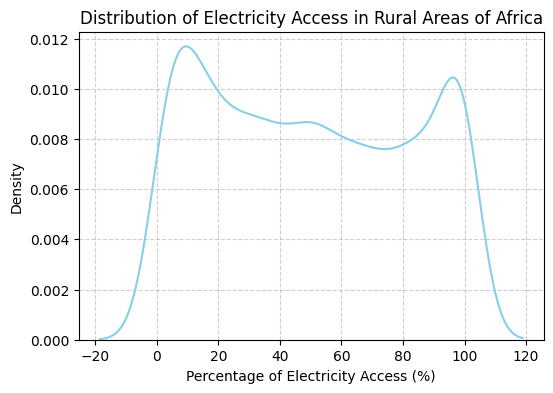

In [ ]:
# Univariate Visualization 1: Distribution of electricity access
plt.figure(figsize=(6, 4))
sns.kdeplot(df_n['Value'].dropna(), fill=False, color='skyblue')
plt.title('Distribution of Electricity Access in Rural Areas of Africa')
plt.xlabel('Percentage of Electricity Access (%)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

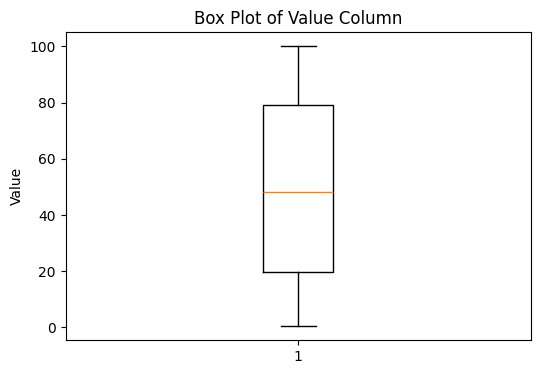

In [ ]:

plt.figure(figsize=(6, 4))
plt.boxplot(df_n['Value'].dropna())

plt.title('Box Plot of Value Column')
plt.ylabel('Value')

plt.show()

 The minimum value of the population with access to electricity is 0.4%. The 1st percentile value is 19.
 62% which implies 25% of the populations in africa have electricity access rate of that. furthermore the median value is ccess percentage is approximately 48.22%. This means that half of the observations have an electricity access rate below 48.22%, and half are above.Third Quartile is at 79.28%. This means 75% of the populations have an electricity access rate at or below this value.
The highest recorded electricity access percentage reaches 100.00%.
The box plot, reveals a highly skewed distribution of electricity access. While some countries achieve nearly universal access (max 100%), a significant portion of the observations (the bottom 25%) have very low access rates, below 19.62%. The large IQR (difference between 79.28% and 19.62%) further emphasizes the substantial disparity in electricity access within the African continent.



multivariate Data Visualizations

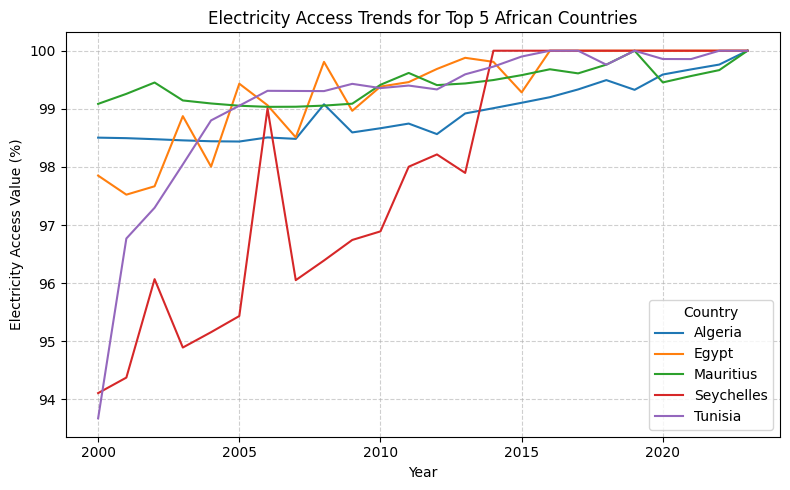

In [ ]:
# Calculate the average value per country
country_avg = df_n.groupby('GeoAreaName/Reference Area Name')['Value'].mean().sort_values(ascending=False)

# Get the top 5 countries
top_5_countries = country_avg.head(5).index

# Filter the DataFrame to include only the top 5 countries
df_top_5 = df_n[df_n['GeoAreaName/Reference Area Name'].isin(top_5_countries)]

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_top_5,
    x='TimePeriod',
    y='Value',
    hue='GeoAreaName/Reference Area Name',
    errorbar=None
)

plt.title('Electricity Access Trends for Top 5 African Countries')
plt.xlabel('Year')
plt.ylabel('Electricity Access Value (%)')
plt.legend(title='Country')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretation: Electricity Access Trends for Top 5 African Countries

This line plot illustrates the electricity access trends over time for the five African countries with the highest average electricity access. We can observe:

  Consistently High Access:Countries like Mauritius, Egypt, and Tunisia demonstrate consistently very high electricity access rates, often hovering close to 100% throughout the observed period. This suggests well-established infrastructure and successful electrification programs.
  Stable Growth or Saturation: For these top-performing countries, the lines are relatively flat or show very gradual upward trends, indicating that they have largely achieved widespread electricity access and are maintaining high levels.
   Minimal Fluctuations: The trends appear stable with minor fluctuations, suggesting a resilient and mature electricity supply system.



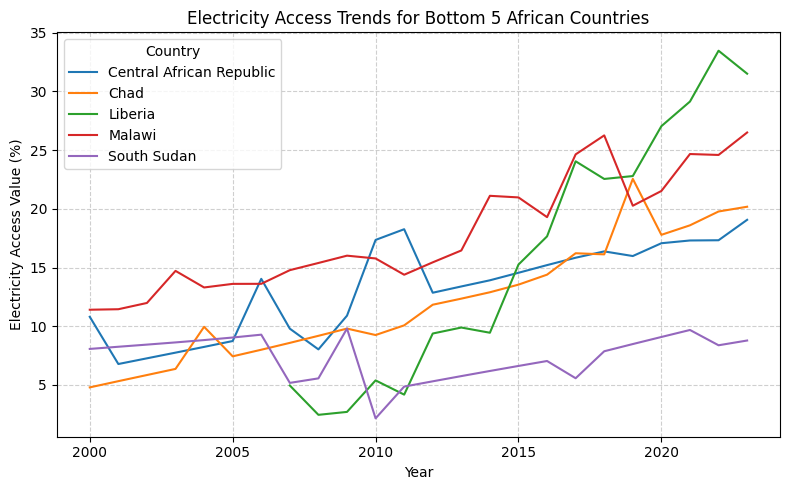

In [ ]:
# Calculate the average value per country
country_avg_bottom = df_n.groupby('GeoAreaName/Reference Area Name')['Value'].mean().sort_values(ascending=True)

# Get the bottom 5 countries
bottom_2_countries = country_avg_bottom.head(5).index

# Filter the DataFrame to include only the bottom 5 countries
df_bottom_2 = df_n[df_n['GeoAreaName/Reference Area Name'].isin(bottom_2_countries)]

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_bottom_2,
    x='TimePeriod',
    y='Value',
    hue='GeoAreaName/Reference Area Name',
    errorbar=None
)

plt.title('Electricity Access Trends for Bottom 5 African Countries')
plt.xlabel('Year')
plt.ylabel('Electricity Access Value (%)')
plt.legend(title='Country')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretation: Electricity Access Trends for Bottom 5 African Countries

This line plot illustrates the electricity access trends over time for the five African countries with the lowest average electricity access. We can observe:

*   **Low Access Levels:** Countries such as South Sudan, Chad, and Central African Republic show consistently very low electricity access rates, often well below 20%. This indicates significant challenges in electrification and limited infrastructure.
*   **Slow or Stagnant Growth:** For many of these countries, the lines are relatively flat or show only marginal upward trends, suggesting that progress in increasing electricity access has been slow or stalled over the observed period.
*   **Vulnerability to Fluctuations:** Some countries might exhibit slight fluctuations, which could be indicative of the fragility of their existing electrical infrastructure or varying reporting methods.

Overall, this visualization highlights the significant disparities in electricity access across Africa, with a group of nations still facing substantial hurdles in providing their populations with reliable power. These countries likely require considerable investment and focused development initiatives to improve their electrification rates.

### Multivariate Visualization: Electricity Access Trends by Rural vs. Urban Areas

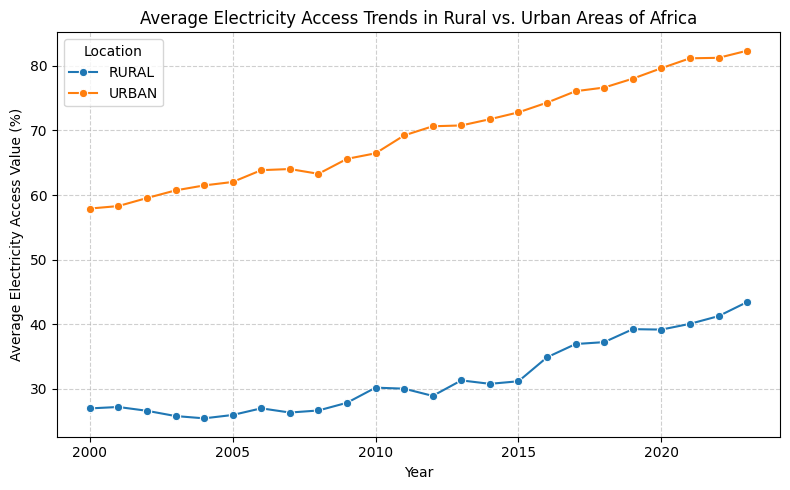

In [ ]:
# Filter data for Rural and Urban locations only
df_rural_urban = df_n[df_n['Location'].isin(['RURAL', 'URBAN'])]

# Group by TimePeriod and Location and calculate the mean Value
df_avg_location = df_rural_urban.groupby(['TimePeriod', 'Location'])['Value'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_avg_location,
    x='TimePeriod',
    y='Value',
    hue='Location',
    errorbar=None,
    marker='o' # Added marker for clarity on distinct data points
)

plt.title('Average Electricity Access Trends in Rural vs. Urban Areas of Africa')
plt.xlabel('Year')
plt.ylabel('Average Electricity Access Value (%)')
plt.legend(title='Location')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretation: Electricity Access Trends in Rural vs. Urban Areas of Africa

This line plot compares the average electricity access rates in rural and urban areas across the African countries in the dataset over time. Key observations include:

*   **Significant Disparity:** There is a clear and consistent gap in electricity access between urban and rural areas. Urban areas consistently show significantly higher access rates compared to rural areas throughout the entire period.
*   **Urban Dominance:** Urban electricity access rates are generally much higher, often reaching or exceeding 70-80%, and show a steady upward trend.
*   **Rural Lag:** Rural areas, while also showing some improvement over time, started at much lower access levels and progress appears slower and more challenging. The rates in rural areas are often below 50% for much of the observed period.
*   **Widening or Persistent Gap:** The visualization suggests that while both areas are improving, the absolute difference in access between urban and rural settings remains substantial, highlighting the ongoing challenge of rural electrification.

This disparity underscores the need for targeted policies and investments to accelerate electrification in rural communities, addressing infrastructure gaps and socio-economic barriers.

Machine Learning:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
# We'll use TimePeriod, GeoAreaName/Reference Area Name (country), and Location to predict Value
X = df_n[['TimePeriod', 'GeoAreaName/Reference Area Name', 'Location']]
y = df_n['Value']

# Identify categorical and numerical features
categorical_features = ['GeoAreaName/Reference Area Name', 'Location']
numerical_features = ['TimePeriod']

# Create a column transformer for preprocessing
# One-hot encode categorical features and pass through numerical features without scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (2908, 3)
Testing features shape: (727, 3)
Training target shape: (2908,)
Testing target shape: (727,)


### Classical Machine Learning Model: RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.pipeline import Pipeline

# Create a pipeline that includes preprocessing and a RandomForestRegressor
model_rf = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(random_state=42))])

# Train the model with cleaned data (df_n is already cleaned, so y_train and X_train are clean)
model_rf.fit(X_train, y_train)

# Make predictions on the test set (X_test is also clean)
y_pred_rf = model_rf.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForestRegressor Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"RandomForestRegressor Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"RandomForestRegressor Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"RandomForestRegressor R-squared (R2): {r2_rf:.2f}")

RandomForestRegressor Mean Absolute Error (MAE): 2.41
RandomForestRegressor Mean Squared Error (MSE): 14.18
RandomForestRegressor Root Mean Squared Error (RMSE): 3.77
RandomForestRegressor R-squared (R2): 0.99


### Neural Network Model

### Classical Machine Learning Model: Linear Regression

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Apply the preprocessor to the full training and testing data first
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the number of features after one-hot encoding from the training data
input_shape = X_train_processed.shape[1]

# Build the Neural Network model
model_nn = Sequential([
    Input(shape=(input_shape,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile the model
model_nn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model_nn.fit(
    X_train_processed, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate the model on the test set
loss_nn, mae_nn = model_nn.evaluate(X_test_processed, y_test, verbose=0)
y_pred_nn = model_nn.predict(X_test_processed).flatten()

# Calculate metrics
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network Mean Absolute Error (MAE): {mae_nn:.2f}")
print(f"Neural Network Mean Squared Error (MSE): {mse_nn:.2f}")
print(f"Neural Network Root Mean Squared Error (RMSE): {rmse_nn:.2f}")
print(f"Neural Network R-squared (R2): {r2_nn:.2f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Neural Network Mean Absolute Error (MAE): 15.39
Neural Network Mean Squared Error (MSE): 349.51
Neural Network Root Mean Squared Error (RMSE): 18.70
Neural Network R-squared (R2): 0.66


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.pipeline import Pipeline

# Create a pipeline that includes preprocessing and a LinearRegression model
model_lr = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

# Train the model (X_train and y_train are already cleaned)
model_lr.fit(X_train, y_train)

# Make predictions on the test set (X_test is also clean)
y_pred_lr = model_lr.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"Linear Regression R-squared (R2): {r2_lr:.2f}")

Linear Regression Mean Absolute Error (MAE): 9.13
Linear Regression Mean Squared Error (MSE): 140.89
Linear Regression Root Mean Squared Error (RMSE): 11.87
Linear Regression R-squared (R2): 0.86


Comparing the models, the RandomForestRegressor clearly outperforms both the Neural Network and Linear Regression models, achieving a much lower MAE, MSE, and RMSE, and a significantly higher R-squared value (0.99). This indicates that the Random Forest model is the most accurate in predicting electricity access percentages for this dataset. The Linear Regression model also performs reasonably well, but not as good as the Random Forest. The Neural Network model had the lowest performance among the three, suggesting it might require further tuning or a different architecture to perform better on this specific task.

### Interactive Model Demo

### Gradio Interface for Model Prediction

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# Define the prediction function that Gradio will call
def predict_electricity_access(model_choice, country, location, year):
    # Create a DataFrame for the new input
    input_data = pd.DataFrame({
        'TimePeriod': [year],
        'GeoAreaName/Reference Area Name': [country],
        'Location': [location]
    })

    if model_choice == "Random Forest":
        prediction = model_rf.predict(input_data)[0]
    elif model_choice == "Neural Network":
        # Preprocess input_data explicitly for the Keras model as it's not in a scikit-learn pipeline
        input_processed = preprocessor.transform(input_data)
        prediction = model_nn.predict(input_processed).flatten()[0]
    elif model_choice == "Linear Regression":
        prediction = model_lr.predict(input_data)[0]
    else:
        return "Error: Invalid model selected."

    return f"{prediction:.2f}%"

# Get unique values for Gradio dropdowns (these should already be available from the ipywidgets setup)
countries = sorted(df_n['GeoAreaName/Reference Area Name'].unique().tolist())
locations = sorted(df_n['Location'].unique().tolist())
min_year = int(df_n['TimePeriod'].min())
max_year = int(df_n['TimePeriod'].max())

# Create Gradio interface
iface = gr.Interface(
    fn=predict_electricity_access,
    inputs=[
        gr.Dropdown(["Random Forest", "Neural Network", "Linear Regression"], label="Select Model", value="Random Forest"),
        gr.Dropdown(countries, label="Country"),
        gr.Dropdown(locations, label="Location Type"),
        gr.Slider(minimum=min_year, maximum=max_year + 5, step=1, value=max_year, label="Year")
    ],
    outputs="text",
    title="Electricity Access Prediction in Africa",
    description="Predict the percentage of population with access to electricity based on country, location type, year, and selected model."
)

# Launch the interface
iface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://44d622685ef3061d5d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
